   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.8/80.8 kB 3.4 MB/s eta 0:00:00


Saving mumbai_daily_weather_2016_2025_demo.csv to mumbai_daily_weather_2016_2025_demo.csv
RAW FILE: mumbai_daily_weather_2016_2025_demo.csv (3653, 4)

Dtypes as read:
 date                      object
mean_temperature_c       float64
rainfall_mm_per_day      float64
mean_humidity_percent    float64

Bad/unparseable dates : 0
Duplicate dates       : 0
Missing calendar days : 0
Missing values per column:
 temp    0
hum     0
rain    0

Cleaned dtypes:
 temp    float64
hum     float64
rain    float64

Range: 2016-01-01 -> 2025-12-31 (3653 days)
          temp      hum     rain
count  3653.00  3653.00  3653.00
mean     28.33    72.19     5.31
std       2.44     7.27    20.16
min      21.70    49.60     0.00
25%      26.40    66.80     0.00
50%      28.40    71.30     0.00
75%      30.30    77.00     0.00
max      35.10    96.10   342.27
Days with rain >= 2.5 mm per year:
 timestamp
2016    62
2017    64
2018    73
2019    67
2020    73
2021    67
2022    71
2023    68
2024    70
2025    79

config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  478MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Chronos-2 loaded on cpu

Step A: choosing best method per variable on 2024 (training < 2024)
  validation 2024 temp: {'chronos': 0.955, 'climatology': 1.001, 'blend': 0.969} -> chronos
  validation 2024 hum: {'chronos': 3.854, 'climatology': 3.808, 'blend': 3.821} -> climatology
  validation 2024 rain monthly-total MAE (mm): {'chronos_daily': 40.7, 'chronos_weekly': 55.6, 'climatology': 33.0, 'blend': 44.3} -> climatology

Step B: forecasting 2025 using data up to 2024-12-31 only. Chosen: {'temp': 'chronos', 'hum': 'climatology', 'rain': 'climatology'}

ACCURACY ON 2025 (model never saw 2025 data)
                    model      variable   MAE   RMSE   bias  corr  monthly_total_MAE_mm  annual_total_pred_mm  annual_total_actual_mm  annual_total_error_pct
       chronos (SELECTED) temperature_c 0.904  1.126 -0.042 0.887                   NaN                   NaN                     NaN                     NaN
              climatology temperature_c 0.978  1.204 -0.458 0.888              

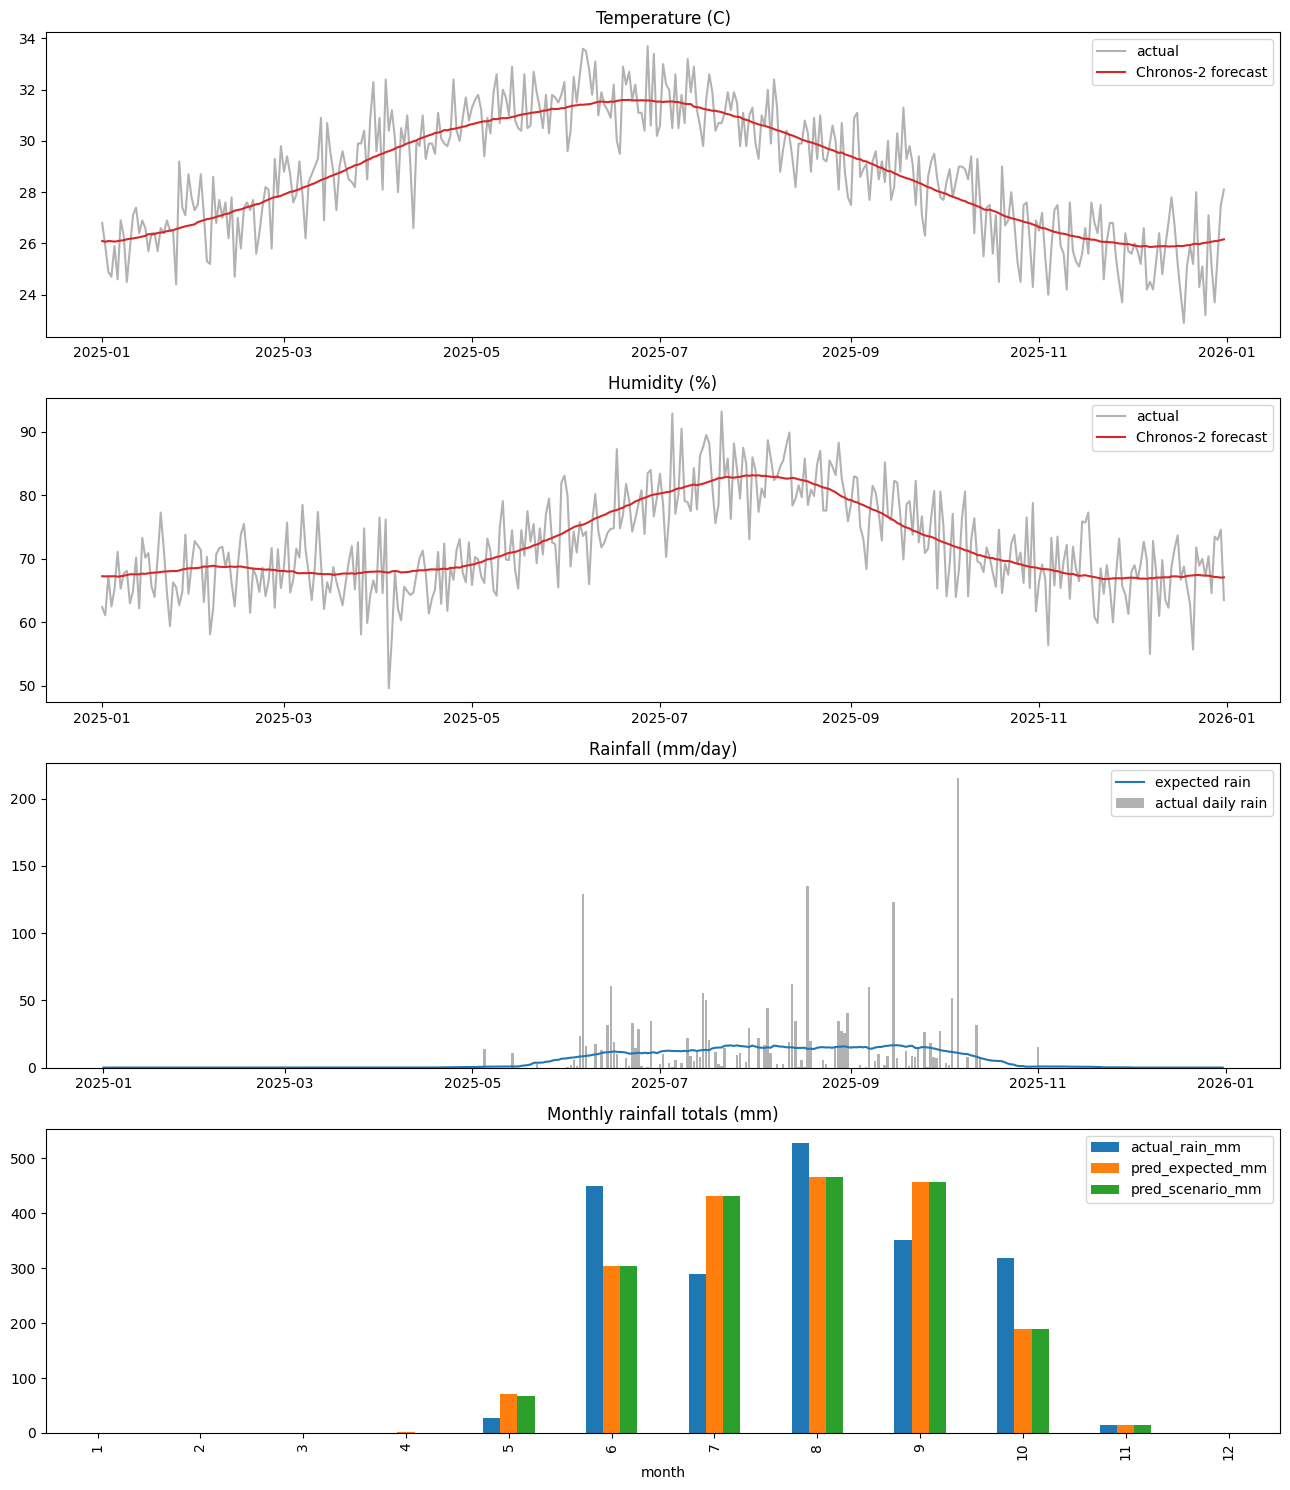


Files written to /content/mumbai_outputs : ['mumbai_2026_forecast.csv', 'mumbai_2025_monthly_rain.csv', 'mumbai_2025_all_model_candidates.csv', 'mumbai_2025_plots.png', 'mumbai_2025_predictions.csv', 'mumbai_2025_metrics.csv']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =====================================================================
#  MUMBAI WEATHER 2025 FORECAST  -  Chronos-2  (single Google Colab script)
#  Temperature + Humidity : Chronos-2 daily forecast, validated vs climatology
#  Rainfall               : Chronos-2 on WEEKLY totals (keeps monsoon volume),
#                           spread to daily, + probabilities + spiky scenario
#  Output                 : CSV files (auto-downloaded at the end)
# =====================================================================
# Colab: Runtime > Change runtime type > T4 GPU (optional, CPU also works)

!pip -q install "chronos-forecasting>=2.1.0" pandas numpy matplotlib

import os, math, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# ------------------------------ CONFIG -------------------------------
HIST_PATH     = "/content/mumbai_daily_weather_2016_2025_demo.csv"          # history csv
OLD_PRED_PATH = "/content/mumbai_2025_FINAL_MASTER_WEATHER__1_.csv"         # optional: your earlier prediction
TEST_YEAR     = 2025          # year to predict (trained ONLY on data before it)
FORECAST_NEXT = True          # also forecast TEST_YEAR+1 using all data
MODEL_ID      = "amazon/chronos-2"
QS            = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
OUT_DIR       = "/content/mumbai_outputs"
SEED          = 42
os.makedirs(OUT_DIR, exist_ok=True)

# Upload prompt if the file isn't already in /content
if not os.path.exists(HIST_PATH):
    from google.colab import files
    up = files.upload()
    for name in up:
        if "2016_2025" in name or "daily" in name.lower():
            HIST_PATH = "/content/" + name
        else:
            OLD_PRED_PATH = "/content/" + name

# ------------------ 1. LOAD + DATA-TYPE CHECKS -----------------------
def load_and_check(path):
    raw = pd.read_csv(path)
    print("=" * 70, "\nRAW FILE:", os.path.basename(path), raw.shape)
    print("\nDtypes as read:\n", raw.dtypes.to_string())
    cols = {c.lower(): c for c in raw.columns}
    pick = lambda key: next(v for k, v in cols.items() if key in k)
    df = pd.DataFrame({
        "date": pd.to_datetime(raw[pick("date")], errors="coerce"),
        "temp": pd.to_numeric(raw[pick("temp")], errors="coerce"),
        "hum":  pd.to_numeric(raw[pick("humid")], errors="coerce"),
        "rain": pd.to_numeric(raw[pick("rain")], errors="coerce"),
    })
    print("\nBad/unparseable dates :", int(df.date.isna().sum()))
    df = df.dropna(subset=["date"]).sort_values("date")
    print("Duplicate dates       :", int(df.date.duplicated().sum()))
    df = df.drop_duplicates("date", keep="last").set_index("date")
    full = pd.date_range(df.index.min(), df.index.max(), freq="D")
    print("Missing calendar days :", len(full) - len(df))
    df = df.reindex(full); df.index.name = "timestamp"
    print("Missing values per column:\n", df.isna().sum().to_string())
    df = df.interpolate(limit=7, limit_direction="both")
    df["rain"] = df["rain"].fillna(0).clip(lower=0)
    df["hum"] = df["hum"].clip(0, 100)
    print("\nCleaned dtypes:\n", df.dtypes.to_string())
    print("\nRange:", df.index.min().date(), "->", df.index.max().date(), f"({len(df)} days)")
    print(df.describe().round(2).to_string())
    print("Days with rain >= 2.5 mm per year:\n",
          (df.rain >= 2.5).groupby(df.index.year).sum().to_string())
    return df

data = load_and_check(HIST_PATH)

# ------------------------ 2. HELPERS ---------------------------------
def cov(idx):
    """Known-in-advance calendar covariates (seasonality) for Chronos-2."""
    d = idx.dayofyear.values
    return pd.DataFrame({
        "sin1": np.sin(2 * np.pi * d / 365.25), "cos1": np.cos(2 * np.pi * d / 365.25),
        "sin2": np.sin(4 * np.pi * d / 365.25), "cos2": np.cos(4 * np.pi * d / 365.25),
    }, index=idx)

def climatology(train, cols, fut_idx, win=15):
    """Smoothed day-of-year average of the training years (circular smoothing)."""
    g = train[cols].groupby(train.index.dayofyear).mean().reindex(range(1, 367)).interpolate()
    ext = pd.concat([g.iloc[-win:], g, g.iloc[:win]])
    sm = ext.rolling(2 * win + 1, center=True, min_periods=1).mean().iloc[win:-win]
    sm.index = range(1, 367)
    out = sm.reindex(fut_idx.dayofyear); out.index = fut_idx
    return out

def qcols(g):
    m = {}
    for c in g.columns:
        try: m[float(c)] = c
        except (TypeError, ValueError): pass
    return m

def split_targets(out, targets):
    out = out.copy()
    if "target_name" not in out.columns:
        out["target_name"] = targets[0]
    return {t: g.set_index("timestamp").sort_index() for t, g in out.groupby("target_name")}

print("\nLoading Chronos-2 ...")
device = "cuda" if torch.cuda.is_available() else "cpu"
from chronos import Chronos2Pipeline
pipe = Chronos2Pipeline.from_pretrained(MODEL_ID, device_map=device)
print("Chronos-2 loaded on", device)

def chronos_daily(train, fut_idx):
    """Temp, humidity (and daily rain) with Chronos-2. Returns dict of quantile frames."""
    targets = ["temp", "hum", "rain"]
    ctx = train[targets].join(cov(train.index)).reset_index()
    ctx.insert(0, "item_id", "MUMBAI")
    fut = cov(fut_idx); fut.index.name = "timestamp"; fut = fut.reset_index()
    fut.insert(0, "item_id", "MUMBAI")
    out = pipe.predict_df(ctx, future_df=fut, prediction_length=len(fut_idx),
                          quantile_levels=QS, id_column="item_id",
                          timestamp_column="timestamp", target=targets)
    res = {}
    for t, g in split_targets(out, targets).items():
        qm = qcols(g)
        q = pd.DataFrame({k: g[v].values for k, v in qm.items()}, index=g.index)
        res[t] = q.reindex(fut_idx)
    return res

def chronos_weekly_rain(train, fut_idx, clim_rain):
    """Rain is spiky. Chronos-2 forecasts WEEKLY totals (much smoother), then the
    weekly total is spread over the 7 days using the historical seasonal shape."""
    tr = train.iloc[len(train) % 7:]                       # make length a multiple of 7
    wk = tr["rain"].resample("7D", origin=tr.index[0]).sum()
    ctx = wk.to_frame("rain")
    mid = ctx.index + pd.Timedelta(days=3)
    ctx = ctx.join(cov(mid).set_index(ctx.index)).reset_index()
    ctx.insert(0, "item_id", "MUMBAI")
    n_wk = math.ceil(len(fut_idx) / 7)
    fw = pd.date_range(wk.index[-1] + pd.Timedelta(days=7), periods=n_wk, freq="7D")
    fut = cov(fw + pd.Timedelta(days=3)).set_index(fw); fut.index.name = "timestamp"
    fut = fut.reset_index(); fut.insert(0, "item_id", "MUMBAI")
    out = pipe.predict_df(ctx, future_df=fut, prediction_length=n_wk, quantile_levels=QS,
                          id_column="item_id", timestamp_column="timestamp", target="rain")
    g = split_targets(out, ["rain"])["rain"]
    qm = qcols(g)
    wk_mean = np.clip(np.mean([g[v].values for v in qm.values()], axis=0), 0, None)  # ~mean of distribution
    daily = pd.Series(0.0, index=fut_idx)
    clim_full = climatology(train, ["rain"], pd.date_range(fw[0], periods=n_wk * 7))["rain"]
    for i, ws in enumerate(fw):
        days = pd.date_range(ws, periods=7)
        w = clim_full.reindex(days).values + 1e-6
        share = pd.Series(wk_mean[i] * w / w.sum(), index=days)
        keep = share.index.isin(fut_idx)
        daily[share.index[keep]] = share[keep].values
    return daily

def rain_probabilities(train, fut_idx, win=15):
    """Historical chance (by day of year, +-15 day window) of a wet / heavy rain day."""
    d = train.index.dayofyear.values; r = train["rain"].values
    def prob(th):
        p = np.zeros(366)
        for k in range(1, 367):
            dist = np.minimum(abs(d - k), 366 - abs(d - k))
            p[k - 1] = (r[dist <= win] >= th).mean()
        return pd.Series(p, index=range(1, 367)).reindex(fut_idx.dayofyear).values
    return prob(0.1), prob(2.5), prob(64.5)   # any rain, >=2.5 mm, IMD 'heavy' (>=64.5 mm)

def rain_scenario(train, fut_idx, daily_expected, win=15, seed=SEED):
    """One realistic SPIKY year (dry spells + downpours) whose monthly totals match the
    forecast. Individual-day timing is a plausible draw, not a day-exact prediction."""
    rng = np.random.default_rng(seed)
    d = train.index.dayofyear.values; r = train["rain"].values
    wet = r >= 0.1
    pools, pw = {}, {}
    for k in range(1, 367):
        dist = np.minimum(abs(d - k), 366 - abs(d - k))
        m = dist <= win
        pools[k] = r[m & wet]; pw[k] = wet[m].mean()
    sim = np.zeros(len(fut_idx))
    for i, k in enumerate(fut_idx.dayofyear):
        if len(pools[k]) and rng.random() < pw[k]:
            sim[i] = rng.choice(pools[k])
    sim = pd.Series(sim, index=fut_idx)
    tgt = daily_expected.groupby(fut_idx.month).sum()
    got = sim.groupby(fut_idx.month).sum()
    for m in tgt.index:
        if got[m] > 0 and tgt[m] > 1:
            sim[fut_idx.month == m] *= np.clip(tgt[m] / got[m], 0.4, 2.5)
        elif tgt[m] <= 1:
            sim[fut_idx.month == m] = 0
    return sim

# ------------------------ 3. FORECAST ENGINE -------------------------
def build_candidates(train, fut_idx):
    """All candidate forecasts for one horizon, from data before fut_idx only."""
    clim = climatology(train, ["temp", "hum", "rain"], fut_idx)
    ch = chronos_daily(train, fut_idx)
    C = pd.DataFrame(index=fut_idx)
    for v in ["temp", "hum"]:
        C[f"{v}__chronos"] = ch[v][0.5].values
        C[f"{v}__climatology"] = clim[v].values
        C[f"{v}__blend"] = 0.5 * C[f"{v}__chronos"] + 0.5 * C[f"{v}__climatology"]
        C[f"{v}__q10"] = ch[v][0.1].values
        C[f"{v}__q90"] = ch[v][0.9].values
    rain_daily_chr = np.clip(ch["rain"].mean(axis=1).values, 0, None)
    rain_wk = chronos_weekly_rain(train, fut_idx, clim["rain"])
    C["rain__chronos_daily"] = rain_daily_chr
    C["rain__chronos_weekly"] = rain_wk.values
    C["rain__climatology"] = clim["rain"].values
    C["rain__blend"] = 0.5 * C["rain__chronos_weekly"] + 0.5 * C["rain__climatology"]
    return C

def mae(a, p):  return float(np.mean(np.abs(np.asarray(a) - np.asarray(p))))
def rmse(a, p): return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(p)) ** 2)))

def monthly_mae(actual, pred):
    return mae(actual.groupby(actual.index.month).sum(), pred.groupby(pred.index.month).sum())

def choose_methods(train_full, val_year):
    """Backtest on the year BEFORE the test year to choose the best method per variable."""
    v_idx = pd.date_range(f"{val_year}-01-01", f"{val_year}-12-31")
    train = train_full.loc[: f"{val_year - 1}-12-31"]
    act = train_full.loc[v_idx]
    C = build_candidates(train, v_idx)
    choice = {}
    for v in ["temp", "hum"]:
        sc = {m: mae(act[v], C[f"{v}__{m}"]) for m in ["chronos", "climatology", "blend"]}
        choice[v] = min(sc, key=sc.get); print(f"  validation {val_year} {v}: {({k: round(x, 3) for k, x in sc.items()})} -> {choice[v]}")
    sc = {m: monthly_mae(act["rain"], pd.Series(C[f"rain__{m}"].values, index=v_idx))
          for m in ["chronos_daily", "chronos_weekly", "climatology", "blend"]}
    choice["rain"] = min(sc, key=sc.get)
    print(f"  validation {val_year} rain monthly-total MAE (mm): {({k: round(x, 1) for k, x in sc.items()})} -> {choice['rain']}")
    return choice

def final_frame(train, fut_idx, choice):
    C = build_candidates(train, fut_idx)
    F = pd.DataFrame(index=fut_idx)
    F["pred_temp_c"] = C[f"temp__{choice['temp']}"]
    F["temp_low_q10"], F["temp_high_q90"] = C["temp__q10"], C["temp__q90"]
    F["pred_humidity_pct"] = C[f"hum__{choice['hum']}"].clip(0, 100)
    F["hum_low_q10"], F["hum_high_q90"] = C["hum__q10"], C["hum__q90"]
    exp = pd.Series(C[f"rain__{choice['rain']}"].values, index=fut_idx).clip(lower=0)
    F["pred_rain_expected_mm"] = exp                       # smooth: best for totals / monthly / seasonal planning
    F["pred_rain_scenario_mm"] = rain_scenario(train, fut_idx, exp)   # spiky, realistic-looking year
    pw, p25, ph = rain_probabilities(train, fut_idx)
    F["prob_any_rain"], F["prob_rain_ge_2.5mm"], F["prob_heavy_rain_ge_64.5mm"] = pw, p25, ph
    F["rain_month_total_pred_mm"] = exp.groupby(fut_idx.month).transform("sum")
    return F, C

# ------------------ 4. BACKTEST ON TEST_YEAR -------------------------
test_idx = pd.date_range(f"{TEST_YEAR}-01-01", f"{TEST_YEAR}-12-31")
have_actual = test_idx[-1] <= data.index.max()
train_test = data.loc[: f"{TEST_YEAR - 1}-12-31"]
print("\n" + "=" * 70, f"\nStep A: choosing best method per variable on {TEST_YEAR - 1} (training < {TEST_YEAR - 1})")
choice = choose_methods(train_test, TEST_YEAR - 1)
print(f"\nStep B: forecasting {TEST_YEAR} using data up to {TEST_YEAR - 1}-12-31 only. Chosen:", choice)
F, C = final_frame(train_test, test_idx, choice)

result = F.copy(); result.insert(0, "date", test_idx.strftime("%Y-%m-%d"))
metrics = []
if have_actual:
    A = data.loc[test_idx]
    result["actual_temp_c"], result["actual_humidity_pct"], result["actual_rain_mm"] = A.temp.values, A.hum.values, A.rain.values
    result["temp_abs_error"] = (F.pred_temp_c - A.temp).abs().values
    result["humidity_abs_error"] = (F.pred_humidity_pct - A.hum).abs().values
    result["rain_abs_error_expected"] = (F.pred_rain_expected_mm - A.rain).abs().values
    def row(name, var, pred, act, extra=None):
        r = {"model": name, "variable": var, "MAE": mae(act, pred), "RMSE": rmse(act, pred),
             "bias": float(np.mean(np.asarray(pred) - np.asarray(act))),
             "corr": float(np.corrcoef(pred, act)[0, 1]) if np.std(pred) > 0 else np.nan}
        if extra: r.update(extra)
        return r
    for v, lab in [("temp", "temperature_c"), ("hum", "humidity_pct")]:
        for m in ["chronos", "climatology", "blend"]:
            metrics.append(row(f"{m}{' (SELECTED)' if m == choice[v] else ''}", lab, C[f"{v}__{m}"], A[v]))
    for m in ["chronos_daily", "chronos_weekly", "climatology", "blend"]:
        p = pd.Series(C[f"rain__{m}"].values, index=test_idx)
        metrics.append(row(f"{m}{' (SELECTED)' if m == choice['rain'] else ''}", "rainfall_mm", p, A.rain,
            {"monthly_total_MAE_mm": monthly_mae(A.rain, p),
             "annual_total_pred_mm": float(p.sum()), "annual_total_actual_mm": float(A.rain.sum()),
             "annual_total_error_pct": float((p.sum() / A.rain.sum() - 1) * 100)}))
    sc = F.pred_rain_scenario_mm
    metrics.append(row("scenario (spiky sample)", "rainfall_mm", sc, A.rain,
        {"monthly_total_MAE_mm": monthly_mae(A.rain, sc), "annual_total_pred_mm": float(sc.sum()),
         "annual_total_actual_mm": float(A.rain.sum()), "annual_total_error_pct": float((sc.sum() / A.rain.sum() - 1) * 100)}))
    metrics.append(row("always-zero rain baseline", "rainfall_mm", np.zeros(len(A)), A.rain,
        {"annual_total_pred_mm": 0.0, "annual_total_actual_mm": float(A.rain.sum()), "annual_total_error_pct": -100.0}))
    # your earlier prediction, if the file is available
    if os.path.exists(OLD_PRED_PATH):
        old = pd.read_csv(OLD_PRED_PATH)
        oc = {k: next(c for c in old.columns if k in c.lower()) for k in ["temp", "humid", "rain"]}
        ot, oh, orn = (old[oc[k]].values[:len(A)] for k in ["temp", "humid", "rain"])
        metrics.append(row("OLD prediction", "temperature_c", ot, A.temp))
        metrics.append(row("OLD prediction", "humidity_pct", oh, A.hum))
        metrics.append(row("OLD prediction", "rainfall_mm", orn, A.rain,
            {"monthly_total_MAE_mm": monthly_mae(A.rain, pd.Series(orn, index=test_idx)),
             "annual_total_pred_mm": float(orn.sum()), "annual_total_actual_mm": float(A.rain.sum()),
             "annual_total_error_pct": float((orn.sum() / A.rain.sum() - 1) * 100)}))
    M = pd.DataFrame(metrics)
    print("\n" + "=" * 70, f"\nACCURACY ON {TEST_YEAR} (model never saw {TEST_YEAR} data)")
    print(M.round(3).to_string(index=False))
    M.round(4).to_csv(f"{OUT_DIR}/mumbai_{TEST_YEAR}_metrics.csv", index=False)
    mt = pd.DataFrame({"actual_rain_mm": A.rain.groupby(A.index.month).sum(),
                       "pred_expected_mm": F.pred_rain_expected_mm.groupby(F.index.month).sum(),
                       "pred_scenario_mm": F.pred_rain_scenario_mm.groupby(F.index.month).sum()}).round(1)
    mt.index.name = "month"; mt.to_csv(f"{OUT_DIR}/mumbai_{TEST_YEAR}_monthly_rain.csv")
    print("\nMonthly rain totals (mm):\n", mt.to_string())

result.round(3).to_csv(f"{OUT_DIR}/mumbai_{TEST_YEAR}_predictions.csv", index=False)
allm = C.copy(); allm.insert(0, "date", test_idx.strftime("%Y-%m-%d"))
allm.round(3).to_csv(f"{OUT_DIR}/mumbai_{TEST_YEAR}_all_model_candidates.csv", index=False)

# ------------------ 5. OPTIONAL: NEXT YEAR ---------------------------
if FORECAST_NEXT:
    nxt = data.index.max().year + 1
    n_idx = pd.date_range(f"{nxt}-01-01", f"{nxt}-12-31")
    print("\n" + "=" * 70, f"\nForecasting {nxt} from all data up to {data.index.max().date()}")
    ch2 = choose_methods(data, data.index.max().year) if data.index.max().month == 12 else choice
    FN, _ = final_frame(data, n_idx, ch2)
    FN.insert(0, "date", n_idx.strftime("%Y-%m-%d"))
    FN.round(3).to_csv(f"{OUT_DIR}/mumbai_{nxt}_forecast.csv", index=False)

# ------------------------ 6. PLOTS -----------------------------------
fig, ax = plt.subplots(4, 1, figsize=(13, 15))
x = test_idx
for a_, v, p, lab in [(ax[0], "temp", "pred_temp_c", "Temperature (C)"), (ax[1], "hum", "pred_humidity_pct", "Humidity (%)")]:
    if have_actual: a_.plot(x, data.loc[x, v], color="gray", alpha=.6, label="actual")
    a_.plot(x, F[p], color="tab:red", label="Chronos-2 forecast"); a_.set_title(lab); a_.legend()
if have_actual: ax[2].bar(x, data.loc[x, "rain"], color="gray", alpha=.6, label="actual daily rain")
ax[2].plot(x, F.pred_rain_expected_mm, color="tab:blue", label="expected rain"); ax[2].set_title("Rainfall (mm/day)"); ax[2].legend()
if have_actual:
    mt.plot.bar(ax=ax[3]); ax[3].set_title("Monthly rainfall totals (mm)")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/mumbai_{TEST_YEAR}_plots.png", dpi=120); plt.show()

# ------------------------ 7. DOWNLOAD --------------------------------
print("\nFiles written to", OUT_DIR, ":", os.listdir(OUT_DIR))
try:
    from google.colab import files
    for f in sorted(os.listdir(OUT_DIR)):
        files.download(os.path.join(OUT_DIR, f))
except Exception as e:
    print("Download manually from the Files panel:", e)